This notebook is used to investigate latent space. Specifically, it allows to apply different clustering/embedding methods, such as **t-SNE**, **k-means**, and **UMAP**. It plots random events of the defined region of a cluster.

In [1]:
import os
import sys
import numpy as np
import random
import tensorflow as tf
from tensorflow import keras
sys.path.append('../../')
from simulated_data.plot_data import plot_event
from clustering import t_SNE_clustering
from clustering import UMAP_embedding
from clustering import k_means_clustering
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits import mplot3d
from matplotlib import colors
import matplotlib.cm as cm

2025-07-10 09:16:57.884302: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-10 09:16:57.943392: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-10 09:16:59.353056: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# create a folder for results of global feature exploration
folder_path = f'../plots/exploration'
os.makedirs(folder_path, exist_ok=True)

Global features are generated using ***global_features_extraction.py***

In [3]:
# load the global features
global_features_O16_Exp = np.load('../global_features/O16_experimental_features.npy')

In [4]:
# load labels
label_data = np.load('../O16_Experimental_Labels.npy')

In [5]:
# sort features in label_data for track identification(for O16 experimental labeled data)
#        0 is 0-,1-,2-track data
#        1 is 3-track data
#        2 is 4-,5-track data

indices = label_data[:, 0].astype(int)
labels = label_data[:, 1].astype(int)

labels = np.where(np.isin(labels, [0, 1, 2]), 0, labels)
labels = np.where(np.isin(labels, [3]), 1, labels)
labels = np.where(np.isin(labels, [4, 5]), 2, labels)

features = global_features_O16_Exp[indices]

In [6]:
# Separate features OR Comment if you have separated features
features_0 = features[labels == 0]
features_1 = features[labels == 1]
features_2 = features[labels == 2]

Applies **k-means** clustering from ***clusering.py***. Edit ***save_dir*** to specify where results will be stored. 

***Sample Invocation of k-means***:

    k_means_clustering(features, labels, dimension, save_dir, num_samples_to_print=10)

In [7]:
save_dir='../plots/k_means'
label_names = ["0,1,2 Tracks", "3 Tracks", "4, 5 Tracks"]

features_glob, cluster_labels, cluster_indices = k_means_clustering(features, labels, 2, save_dir, label_names, num_samples_to_print=10)


Random sample indices from each cluster:
Cluster 0: [1680, 1751, 1976, 686, 2436, 1937, 1564, 259, 882, 307]
Cluster 1: [1463, 625, 2300, 770, 1641, 542, 980, 2262, 2158, 2066]
Cluster 2: [1957, 1019, 1044, 1007, 1503, 620, 1305, 515, 1287, 1079]


Transforms indices sampled after clustering into ones that can be used to navigate through original events.

In [8]:
def transform_ids(cluster_ids, original_ids):
    original = []

    for index in cluster_ids:
        original.append(original_ids[index])
    return original

clusters = []
print("Transformed indices:")
for i, cluster in enumerate(cluster_indices):
    clusters.append(transform_ids(cluster, indices))
    print(f"Cluster {i}: {clusters[i]}")

Transformed indices:
Cluster 0: [13123, 17034, 31268, 686, 45824, 28852, 9177, 259, 882, 307]
Cluster 1: [3528, 625, 43850, 770, 11277, 542, 980, 43497, 38779, 34952]
Cluster 2: [29907, 1019, 1044, 1007, 5815, 620, 1492, 515, 1474, 1079]


Prints true labels (Optional part for visualization).

In [9]:
def extract_true_labels(indices, labels):
    c_labels = []
    for index in indices:
        c_labels.append(labels[index])

    return c_labels

print("True labels: ")
true_labels = []
for i, cluster in enumerate(cluster_indices):
    true_labels.append(extract_true_labels(cluster, labels))
    print(f"Cluster {i}: {true_labels[i]}")

True labels: 
Cluster 0: [2, 2, 2, 0, 1, 2, 2, 0, 0, 0]
Cluster 1: [2, 0, 1, 0, 1, 0, 0, 1, 2, 2]
Cluster 2: [2, 0, 0, 0, 2, 0, 0, 0, 0, 0]


Plots events using provided indices. Edit ***events*** to specify the location of the original data. 

In [10]:
def plot_events(indices, name, events, true_labels, cols=3):
    rows = int(np.ceil(len(indices) / cols))
    fig = plt.figure(figsize=(5 * cols, 5 * rows))

    folder_path = f'../plots/exploration/k_means/{name}/'
    os.makedirs(folder_path, exist_ok=True)

    for i, index in enumerate(indices):
        ax = fig.add_subplot(rows, cols, i + 1, projection='3d')
        plot_event(fig, events, index, ax)
        ax.set_title(f"Event: {index} | Label: {true_labels[i]}")        

    plt.tight_layout()
    plt.savefig(f'{folder_path}/matrix_plot.png')
    plt.close()

events = np.load("../../data_processing/O16/voxel_data/O16_size512.npy")
for i, cluster in enumerate(clusters):
    plot_events(cluster, f"cluster_{i}", events, true_labels[i])

**This section plots events of a particular region.**
- Change j to specify how many events to be plotted
- Change x1,x2,y1,y2 to set the boundaries of a region.

In [11]:
def plot_selected_events(data, sampled_data, folder_path):
    fig = plt.figure()
    ax = fig.add_subplot(111) 

    j = 6
    i = random.randint(0, len(data) - 1) # corresponds to the random event
    maxim = 0
    while j != 0:  # number of events to be plotted
        # change the boundaries of a region
        x1 = 4
        y1 = 13
        x2 = 5
        y2 = 15

        if (maxim == len(data)): # solves an infinite for-loop problem
            break

        if (data[i][0] > x1 and data[i][0] < x2 and data[i][1] > y1 and data[i][1] < y2):
            fig = plt.figure(figsize=(10, 10))
            plot_event(fig, sampled_data, i)
            plt.savefig(f'{folder_path}/event_{i}.png')
            j-=1
        i = random.randint(0, len(data) - 1)
        maxim+=1

Applies **UMAP** embedding from ***clusering.py*** and saves the result in *../plots/exploration/umap*

In [29]:
# apply UMAP embedding
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111)
neighbors = 35 # change or leave it

umap_0 = UMAP_embedding(features_0, 2, ax, 'red', '0,1,2 Tracks', 0.5, neighbors)
umap_1 = UMAP_embedding(features_1, 2, ax, 'blue', '3 Tracks', 0.5, neighbors)
umap_2 = UMAP_embedding(features_2, 2, ax, 'green', '4, 5 Tracks', 0.5, neighbors)
fig.legend()
plt.title("UMAP 2D Embedding of Experimental Labeled O16")

folder_path = '../plots/umap'
os.makedirs(folder_path, exist_ok=True)  

plt.savefig(f'{folder_path}/umap_n_{neighbors}.png')
plt.close()

[[12.412874   8.715712 ]
 [ 9.439624  14.371469 ]
 [12.811962   6.7700906]
 ...
 [ 2.915667  14.746161 ]
 [ 2.080844  13.64791  ]
 [ 6.857639  14.447705 ]]
[[-6.75409842e+00  5.03142405e+00]
 [ 5.93193054e+00  5.91531610e+00]
 [-1.83740711e+00  5.75750685e+00]
 [ 1.32430000e+01  5.82901907e+00]
 [ 1.99332964e+00  6.40263844e+00]
 [ 2.57225227e+00  5.97058058e+00]
 [ 2.03941083e+00  6.56885672e+00]
 [-3.62926459e+00  5.38425446e+00]
 [ 1.02965069e+01  6.18320990e+00]
 [ 9.97054577e+00  5.43080521e+00]
 [ 3.14718366e+00  5.62918615e+00]
 [ 2.76522231e+00  5.85179424e+00]
 [ 1.18543358e+01  5.74330044e+00]
 [ 9.40140820e+00  5.76194048e+00]
 [-1.92671418e+00  5.86290741e+00]
 [ 6.02654934e+00  5.75991201e+00]
 [-5.54569438e-02  5.74658442e+00]
 [ 2.99045134e+00  6.29272461e+00]
 [ 3.67865348e+00  6.25966787e+00]
 [ 4.59448004e+00  6.68455696e+00]
 [ 4.45886946e+00  6.75975895e+00]
 [-2.69526315e+00  5.16330719e+00]
 [ 2.19864279e-01  5.72519064e+00]
 [-3.24238515e+00  5.47782946e+00]
 [ 6

In [13]:
O16_experimental_data = np.load('../../data_processing/O16/voxel_data/O16_size512.npy')
experimental_data = O16_experimental_data[indices]

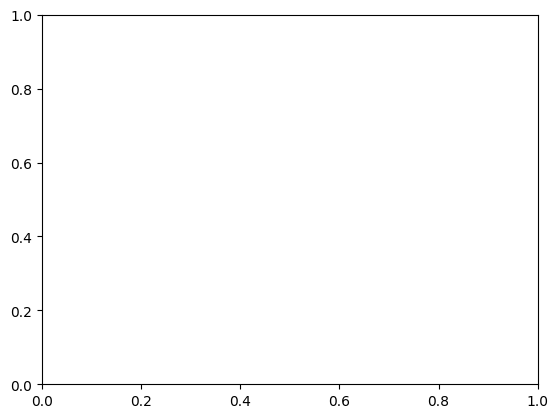

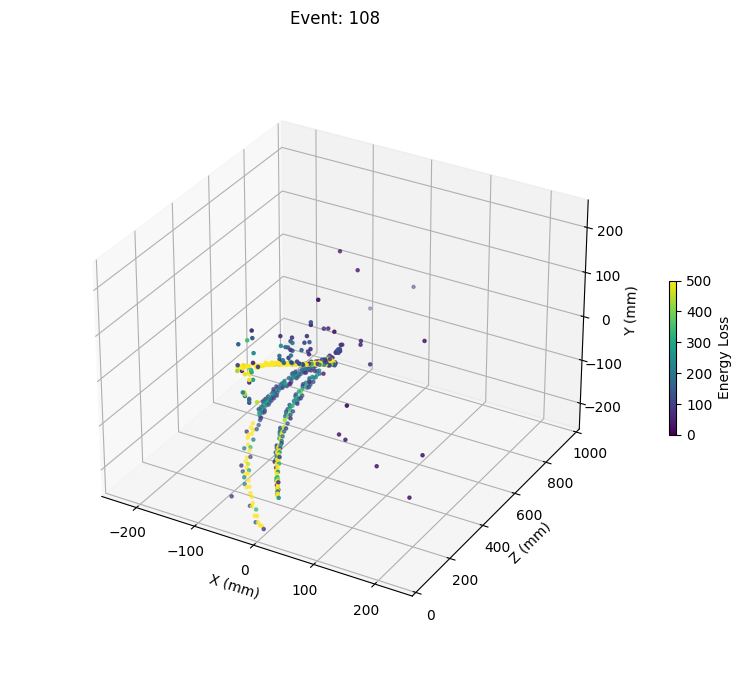

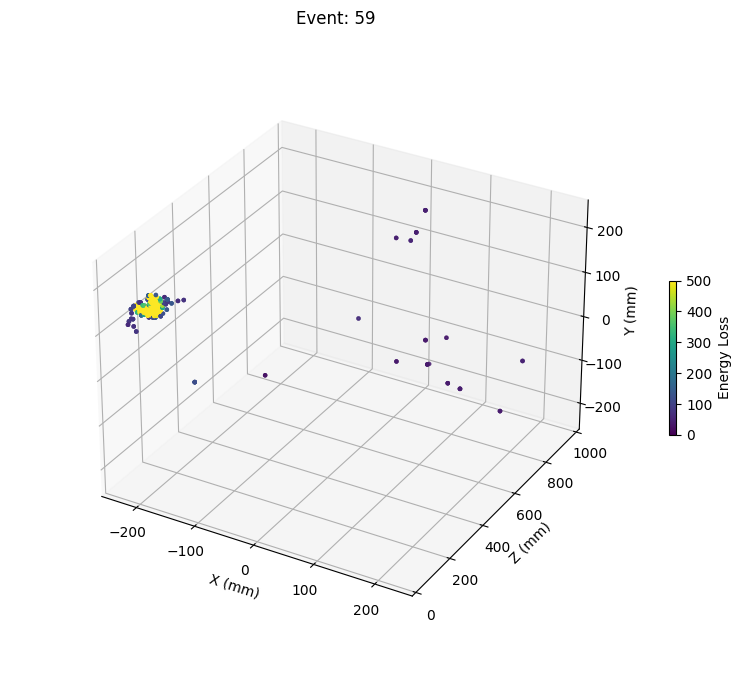

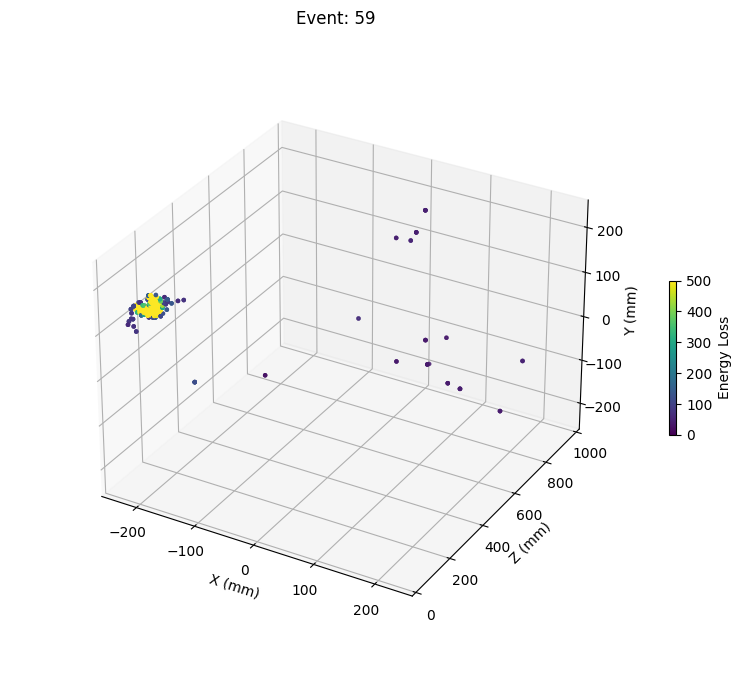

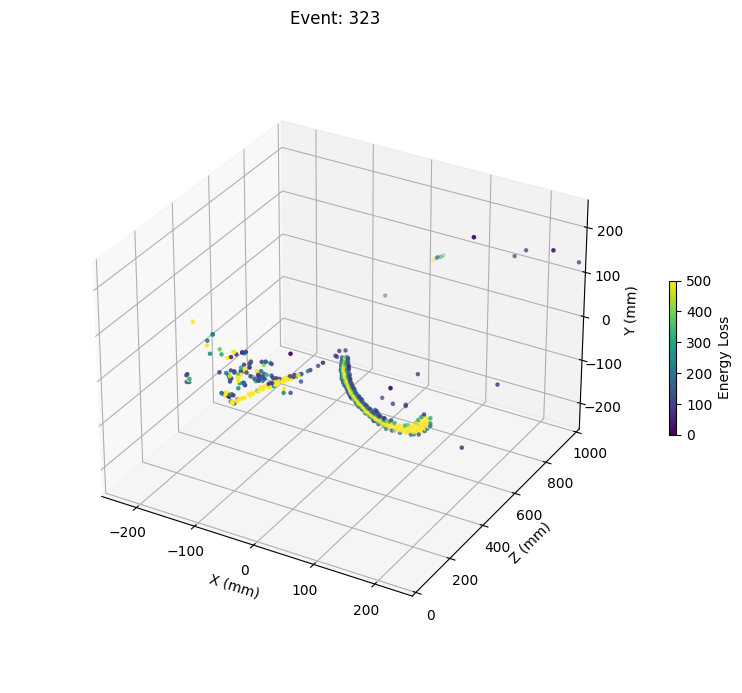

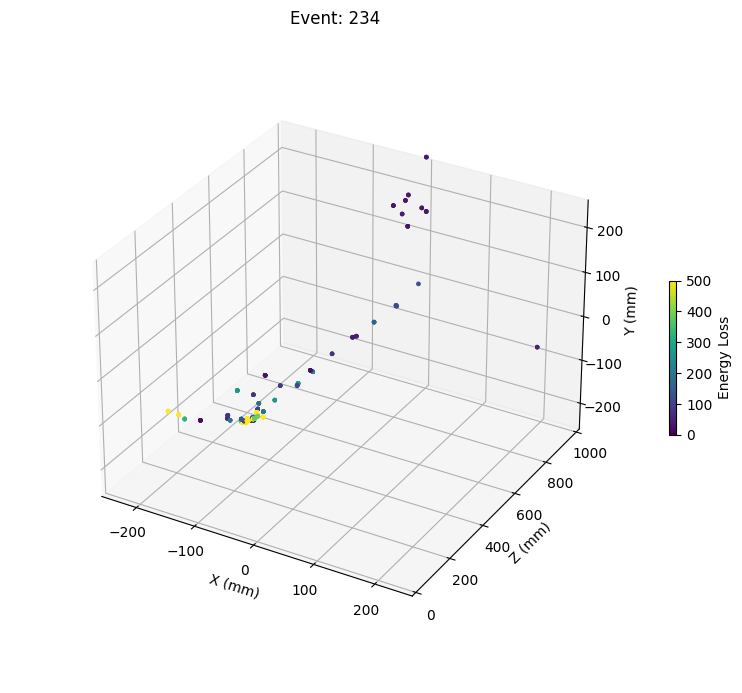

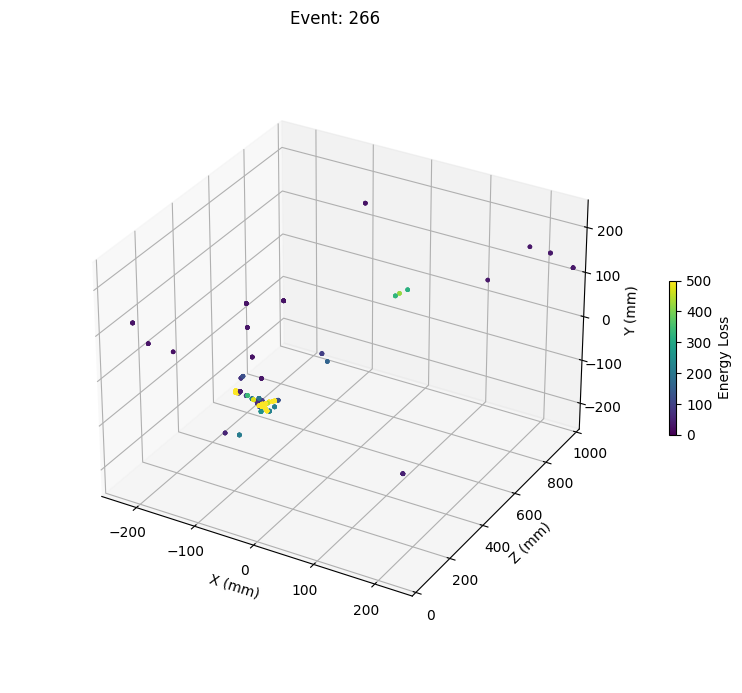

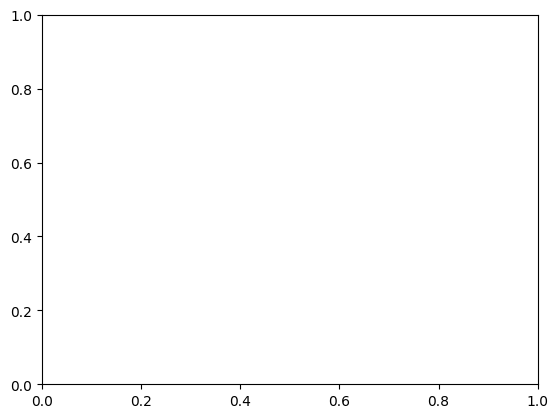

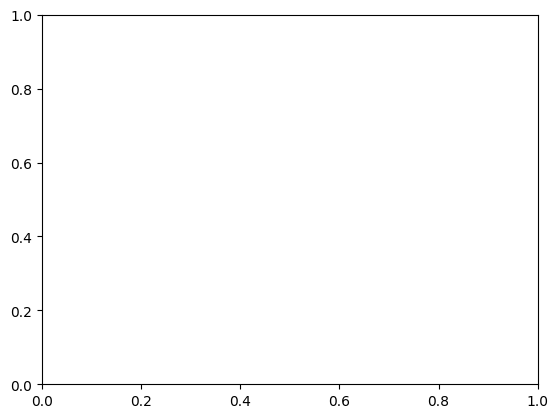

In [14]:
#Plots events of a defined region. Change x1,x2,y1,y2 to set the boundaries of a region in the plot_selected_events section.
# plot_selected_events(data, sampled_data, folder_path)
#    data - clustered data 
#    sampled_data - point cloud data from which random point will be printed
#    folder_path - where files will be saved

name = '0,1,2 Tracks'
folder_path = f'../plots/exploration/umap/{name}/'
os.makedirs(folder_path, exist_ok=True)
plot_selected_events(umap_0, experimental_data, folder_path)

name = '3 Tracks'
folder_path = f'../plots/exploration/umap/{name}/'
os.makedirs(folder_path, exist_ok=True)
plot_selected_events(umap_1, experimental_data, folder_path)

name = '4, 5 Tracks'
folder_path = f'../plots/exploration/umap/{name}/'
os.makedirs(folder_path, exist_ok=True)
plot_selected_events(umap_2, experimental_data, folder_path)

Applies **T-SNE** embedding from ***clusering.py*** and saves the result in *../plots/exploration/t_sne*

In [23]:
# apply T-SNE embedding
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111)
perplexity = 35 # change or leave it

tsne_0 = t_SNE_clustering(features_0, 2, ax, 'red', '0,1,2 Tracks', 0.5, perplexity)
tsne_1 = t_SNE_clustering(features_1, 2, ax, 'blue', '3 Tracks', 0.5, neighbors)
tsne_2 = t_SNE_clustering(features_2, 2, ax, 'green', '4, 5 Tracks', 0.5, neighbors)
fig.legend()
plt.title("T-SNE 2D Embedding of Experimental Labeled O16")

folder_path = '../plots/tsne'
os.makedirs(folder_path, exist_ok=True)  

plt.savefig(f'{folder_path}/tsne_p_{perplexity}.png')
plt.close()

In [16]:
O16_experimental_data = np.load('../../data_processing/O16/voxel_data/O16_size512.npy')
experimental_data = O16_experimental_data[indices]

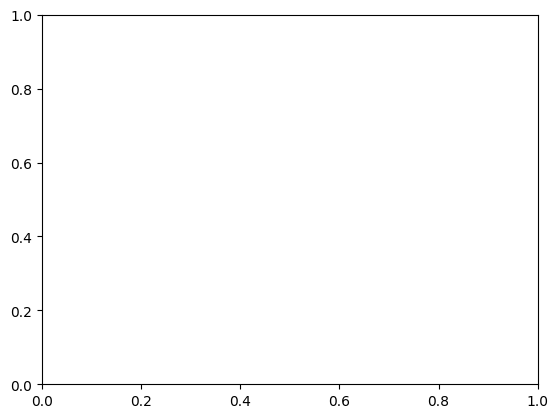

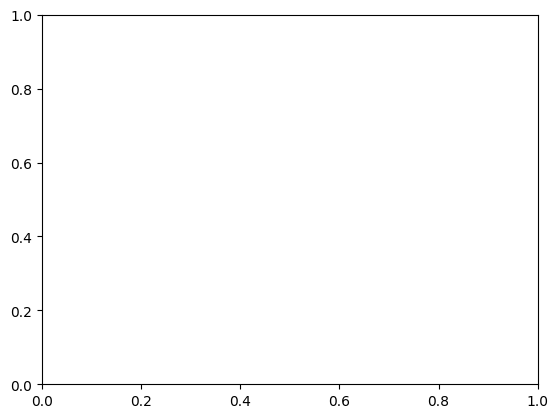

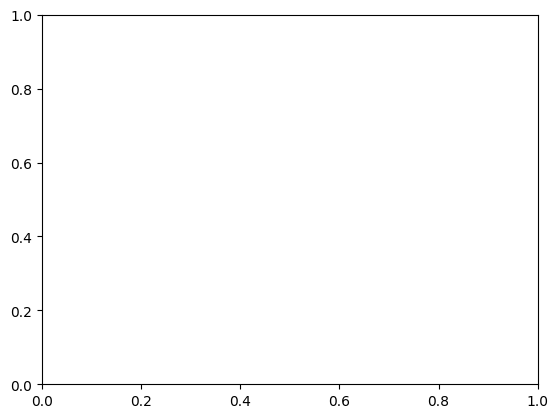

In [17]:
#Plots events of a defined region. Change x1,x2,y1,y2 to set the boundaries of a region in the plot_selected_events section.
# plot_selected_events(data, sampled_data, folder_path)
#    data - clustered data 
#    sampled_data - point cloud data from which random point will be printed
#    folder_path - where files will be saved

name = '0,1,2 Tracks'
folder_path = f'../plots/exploration/tsne/{name}/'
os.makedirs(folder_path, exist_ok=True)
plot_selected_events(tsne_0, experimental_data, folder_path)

name = '3 Tracks'
folder_path = f'../plots/exploration/tsne/{name}/'
os.makedirs(folder_path, exist_ok=True)
plot_selected_events(tsne_1, experimental_data, folder_path)

name = '4, 5 Tracks'
folder_path = f'../plots/exploration/tsne/{name}/'
os.makedirs(folder_path, exist_ok=True)
plot_selected_events(tsne_2, experimental_data, folder_path)